# Tissue Classification — Walkthrough


In [1]:
import os
import glob
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
import tifffile
import torch
from PIL import Image

sns.set_theme(style="whitegrid")


# Part 1 — Data and leakage Check


Before training any model, we need to understand what we are working with. Let's start from scratch and see what the data actually looks like.



## Step 1 – What's in the data folder?



In [2]:
DATA_DIR = "data"

classes = sorted([
    d for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d))
])
print("Subdirectories found:", classes)

records = []
for cls in classes:
    paths = sorted(glob.glob(os.path.join(DATA_DIR, cls, "*.tif")))
    for p in paths:
        records.append({"class": cls, "path": p})

df = pd.DataFrame(records)
print(f"\nTotal images: {len(df)}")
print(df["class"].value_counts().sort_index().to_string())


Subdirectories found: ['class1', 'class2', 'class3', 'class4']

Total images: 400
class
class1    100
class2    100
class3    100
class4    100


## Step 2 – A first look at the images



Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [2570..65535].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0..65535].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0..65535].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [6425..65535].


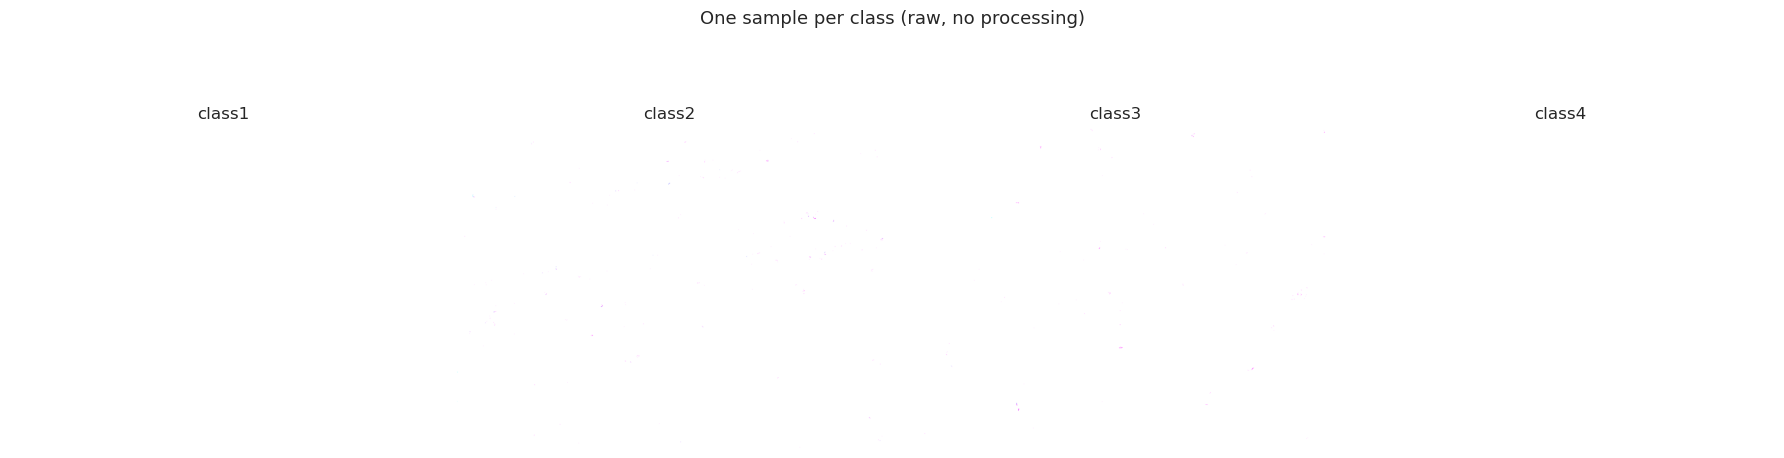

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, cls in zip(axes, classes):
    sample_path = df[df["class"] == cls]["path"].iloc[0]
    img = tifffile.imread(sample_path)
    ax.imshow(img)
    ax.set_title(cls)
    ax.axis("off")

plt.suptitle("One sample per class (raw, no processing)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


## Step 3 – Something looks off

The images are displaying but they are white.

Let's print  `dtype`, `shape`, `min`, and `max`.


In [4]:
for cls in classes:
    sample_path = df[df["class"] == cls]["path"].iloc[0]
    img = tifffile.imread(sample_path)
    print(f"{cls}  |  shape: {img.shape}  |  dtype: {img.dtype}  |  min: {img.min():6}  |  max: {img.max():6}")


class1  |  shape: (1536, 2048, 3)  |  dtype: uint16  |  min:   2570  |  max:  65535
class2  |  shape: (1536, 2048, 3)  |  dtype: uint16  |  min:      0  |  max:  65535
class3  |  shape: (1536, 2048, 3)  |  dtype: uint16  |  min:      0  |  max:  65535
class4  |  shape: (1536, 2048, 3)  |  dtype: uint16  |  min:   6425  |  max:  65535


## Step 4 –  the bit-depth issue

Some images the max value is around `65535` instead of `255`?
That's a **16-bit unsigned integer** (`uint16`), not 8-bit (`uint8`).


| Type | Range | Bits |
|---|---|---|
| `uint8` | 0 – 255 | 8 |
| `uint16` | 0 – 65 535 | 16 |

If we pass both to a neural network without normalization, the 16-bit images will dominate
the 8-bit ones by a factor of up to 256x. Let's see how widespread this issue is.


In [5]:
dtype_counts = Counter()

for path in df["path"]:
    img = tifffile.imread(path)
    dtype_counts[str(img.dtype)] += 1

print("Bit-depth breakdown across the full dataset:")
for dtype, count in sorted(dtype_counts.items()):
    pct = count / len(df) * 100
    print(f"  {dtype:8s}  {count:4d} images  ({pct:.1f}%)")


Bit-depth breakdown across the full dataset:
  uint16     381 images  (95.2%)
  uint8       19 images  (4.8%)


### Is the mixing per-class or random?

Let's break it down per class to understand the pattern.


In [6]:
records_with_dtype = []
for _, row in df.iterrows():
    img = tifffile.imread(row["path"])
    records_with_dtype.append({
        "class": row["class"],
        "path":  row["path"],
        "dtype": str(img.dtype),
        "min":   int(img.min()),
        "max":   int(img.max()),
        "shape": img.shape,
    })

df_meta = pd.DataFrame(records_with_dtype)

print(df_meta.groupby(["class", "dtype"]).size().rename("count").to_string())


class   dtype 
class1  uint16     89
        uint8      11
class2  uint16    100
class3  uint16     96
        uint8       4
class4  uint16     96
        uint8       4


In [7]:
unique_shapes = df_meta["shape"].value_counts()
print(f"Unique image shapes across all {len(df_meta)} files: {len(unique_shapes)}")


Unique image shapes across all 400 files: 1


In [8]:
unique_shapes

shape
(1536, 2048, 3)    400
Name: count, dtype: int64

## Step 5 – Making the problem visible

All shapes are `(1536, 2048, 3)`, which means the resolution is consistent.
But the mixing happens *within* each class.

Let's now display 8-bit and a 16-bit image side by side in two ways:

1. **As numpy sees them** – raw pixel values fed directly to imshow with a fixed scale `[0, 255]`
2. **As matplotlib auto-scales them** – which is what we saw before 


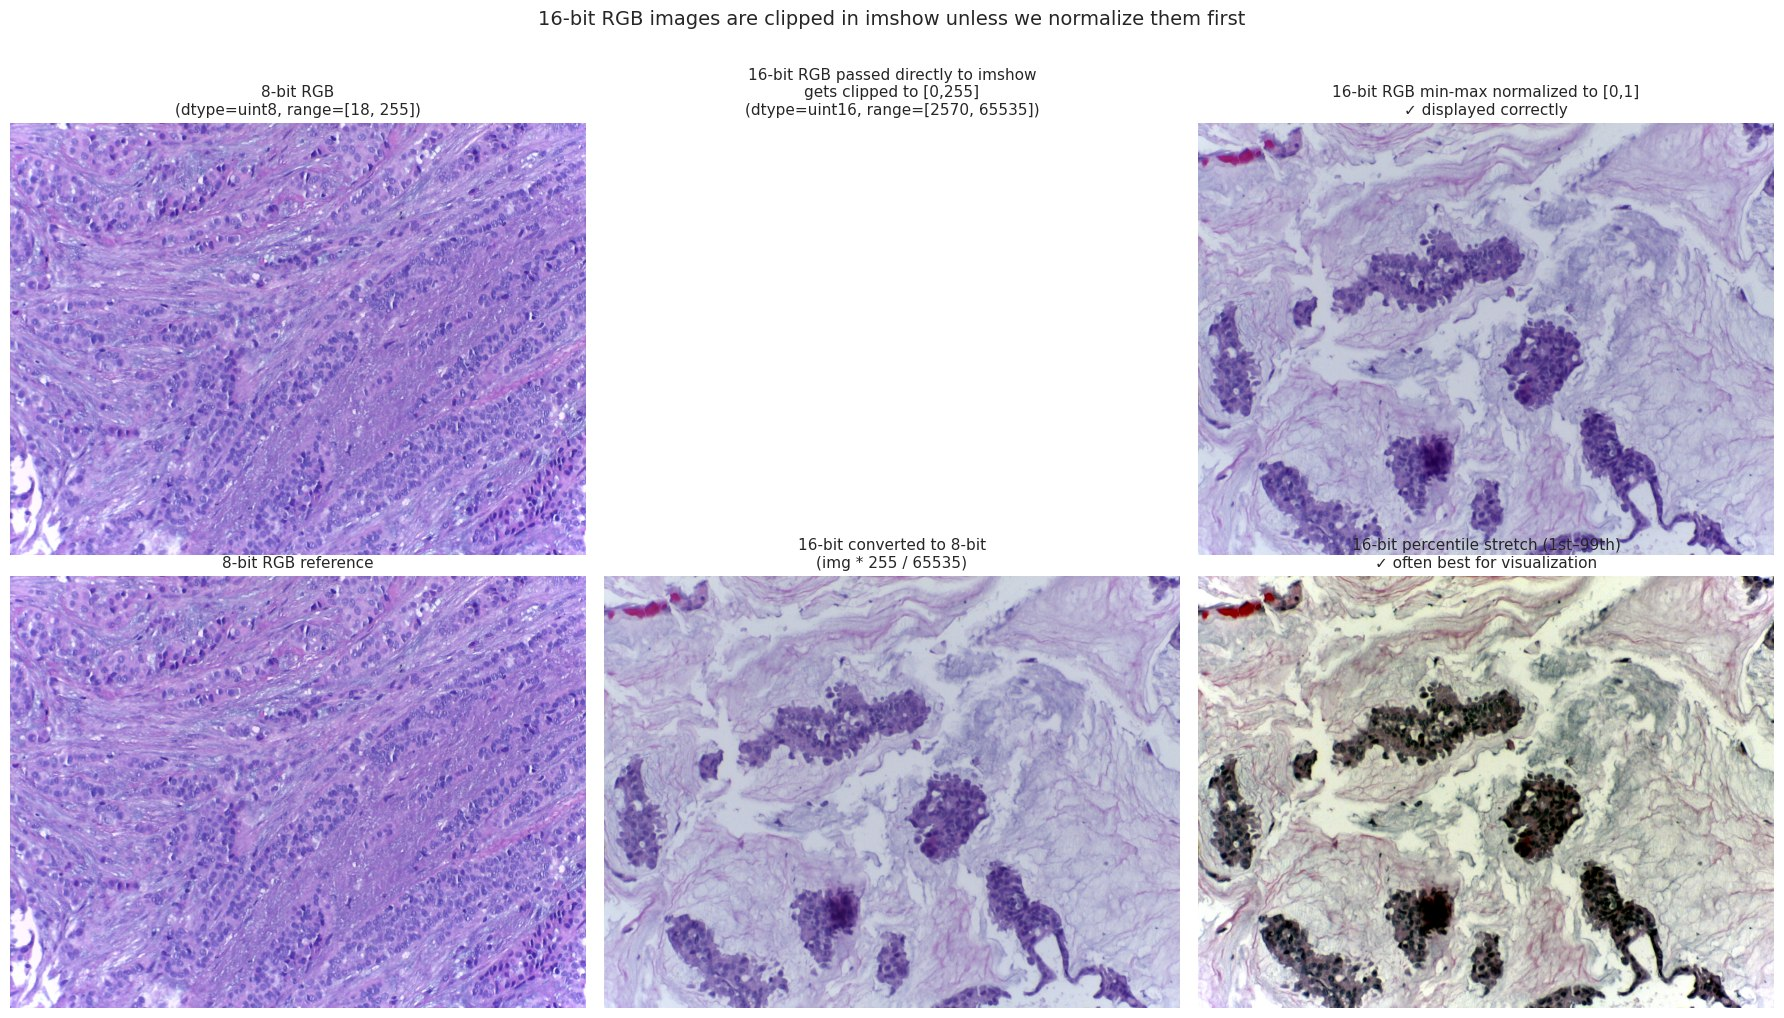

In [9]:
eight_bit_row   = df_meta[df_meta["dtype"] == "uint8"].iloc[0]
sixteen_bit_row = df_meta[df_meta["dtype"] == "uint16"].iloc[0]

img_8  = tifffile.imread(eight_bit_row["path"])
img_16 = tifffile.imread(sixteen_bit_row["path"])


def minmax_float_display(img):
    img = img.astype(np.float32)
    lo, hi = img.min(), img.max()
    if hi == lo:
        return np.zeros_like(img, dtype=np.float32)
    return (img - lo) / (hi - lo)

def convert_16_to_8bit(img):
    return np.round(img.astype(np.float32) * (255.0 / 65535.0)).astype(np.uint8)

def percentile_stretch(img, p_low=1, p_high=99):
    img = img.astype(np.float32)
    lo = np.percentile(img, p_low, axis=(0, 1), keepdims=True)
    hi = np.percentile(img, p_high, axis=(0, 1), keepdims=True)
    stretched = (img - lo) / (hi - lo + 1e-8)
    return np.clip(stretched, 0, 1)

# What matplotlib effectively does to 16-bit RGB integers:
# it clips values outside [0, 255]
img_16_clipped = np.clip(img_16, 0, 255).astype(np.uint8)

# Two correct display options
img_16_u8      = convert_16_to_8bit(img_16)
img_16_norm    = minmax_float_display(img_16)
img_16_pstretch = percentile_stretch(img_16, 1, 99)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: what is actually happening
axes[0, 0].imshow(img_8)
axes[0, 0].set_title(
    f"8-bit RGB\n(dtype={img_8.dtype}, range=[{img_8.min()}, {img_8.max()}])",
    fontsize=11
)
axes[0, 0].axis("off")

axes[0, 1].imshow(img_16_clipped)
axes[0, 1].set_title(
    f"16-bit RGB passed directly to imshow\n"
    f"gets clipped to [0,255]\n"
    f"(dtype={img_16.dtype}, range=[{img_16.min()}, {img_16.max()}])",
    fontsize=11
)
axes[0, 1].axis("off")

axes[0, 2].imshow(img_16_norm)
axes[0, 2].set_title(
    "16-bit RGB min-max normalized to [0,1]\n✓ displayed correctly",
    fontsize=11
)
axes[0, 2].axis("off")
axes[0, 0].set_ylabel("what imshow does", fontsize=12, labelpad=10)

# Row 2: practical fixes
axes[1, 0].imshow(img_8)
axes[1, 0].set_title("8-bit RGB reference", fontsize=11)
axes[1, 0].axis("off")

axes[1, 1].imshow(img_16_u8)
axes[1, 1].set_title(
    "16-bit converted to 8-bit\n(img * 255 / 65535)",
    fontsize=11
)
axes[1, 1].axis("off")

axes[1, 2].imshow(img_16_pstretch)
axes[1, 2].set_title(
    "16-bit percentile stretch (1st–99th)\n✓ often best for visualization",
    fontsize=11
)
axes[1, 2].axis("off")
axes[1, 0].set_ylabel("practical fixes", fontsize=12, labelpad=10)

plt.suptitle(
    "16-bit RGB images are clipped in imshow unless we normalize them first",
    fontsize=14,
    y=1.02
)
plt.tight_layout()
plt.show()

## Step 6 – Choosing a normalization strategy

Now that we've made the bit-depth mismatch visible, we have to pick a consistent way to load
images. We can choose two reasonable options:

**Option A — rescale 16-bit to 8-bit at load time.**
For every 16-bit image, divide by 256 (equivalent to `>> 8`) and cast to `uint8`. Every image
downstream is `uint8` in `[0, 255]`, regardless of how it was stored on disk.

**Option B — load everything as float in `[0, 1]`.**
Divide 8-bit images by 255 and 16-bit images by 65535. This will preserve any finer gradations that
the 16-bit images might genuinely carry, since their extra precision isn't faded away.


Let's go with **Option A** for now: collapse everything to `uint8` in `load_image`, and let the standard
transforms pipeline take it from there (`ToTensor` → `/255` → ImageNet `Normalize`). 


In [10]:
def load_image(path: str) -> np.ndarray:
    """Load a TIFF and ensure 8-bit uint8 output."""
    img = tifffile.imread(path)
    if img.dtype == np.uint16:
        img = (img >> 8).astype(np.uint8)   # equivalent to // 256
    return img


# Quick sanity check — one example of each original dtype
for input_dtype, group in df_meta.groupby("dtype"):
    sample_path = group["path"].iloc[0]
    img = load_image(sample_path)
    print(f"Input dtype: {input_dtype:8s}  →  Output dtype: {img.dtype},  "
          f"min: {img.min():3d},  max: {img.max():3d}")


Input dtype: uint16    →  Output dtype: uint8,  min:  10,  max: 255
Input dtype: uint8     →  Output dtype: uint8,  min:  18,  max: 255


## Step 7 – What the data actually looks like

Ok, Now, let's display a proper gallery:
3 random images from each class, all correctly normalised.


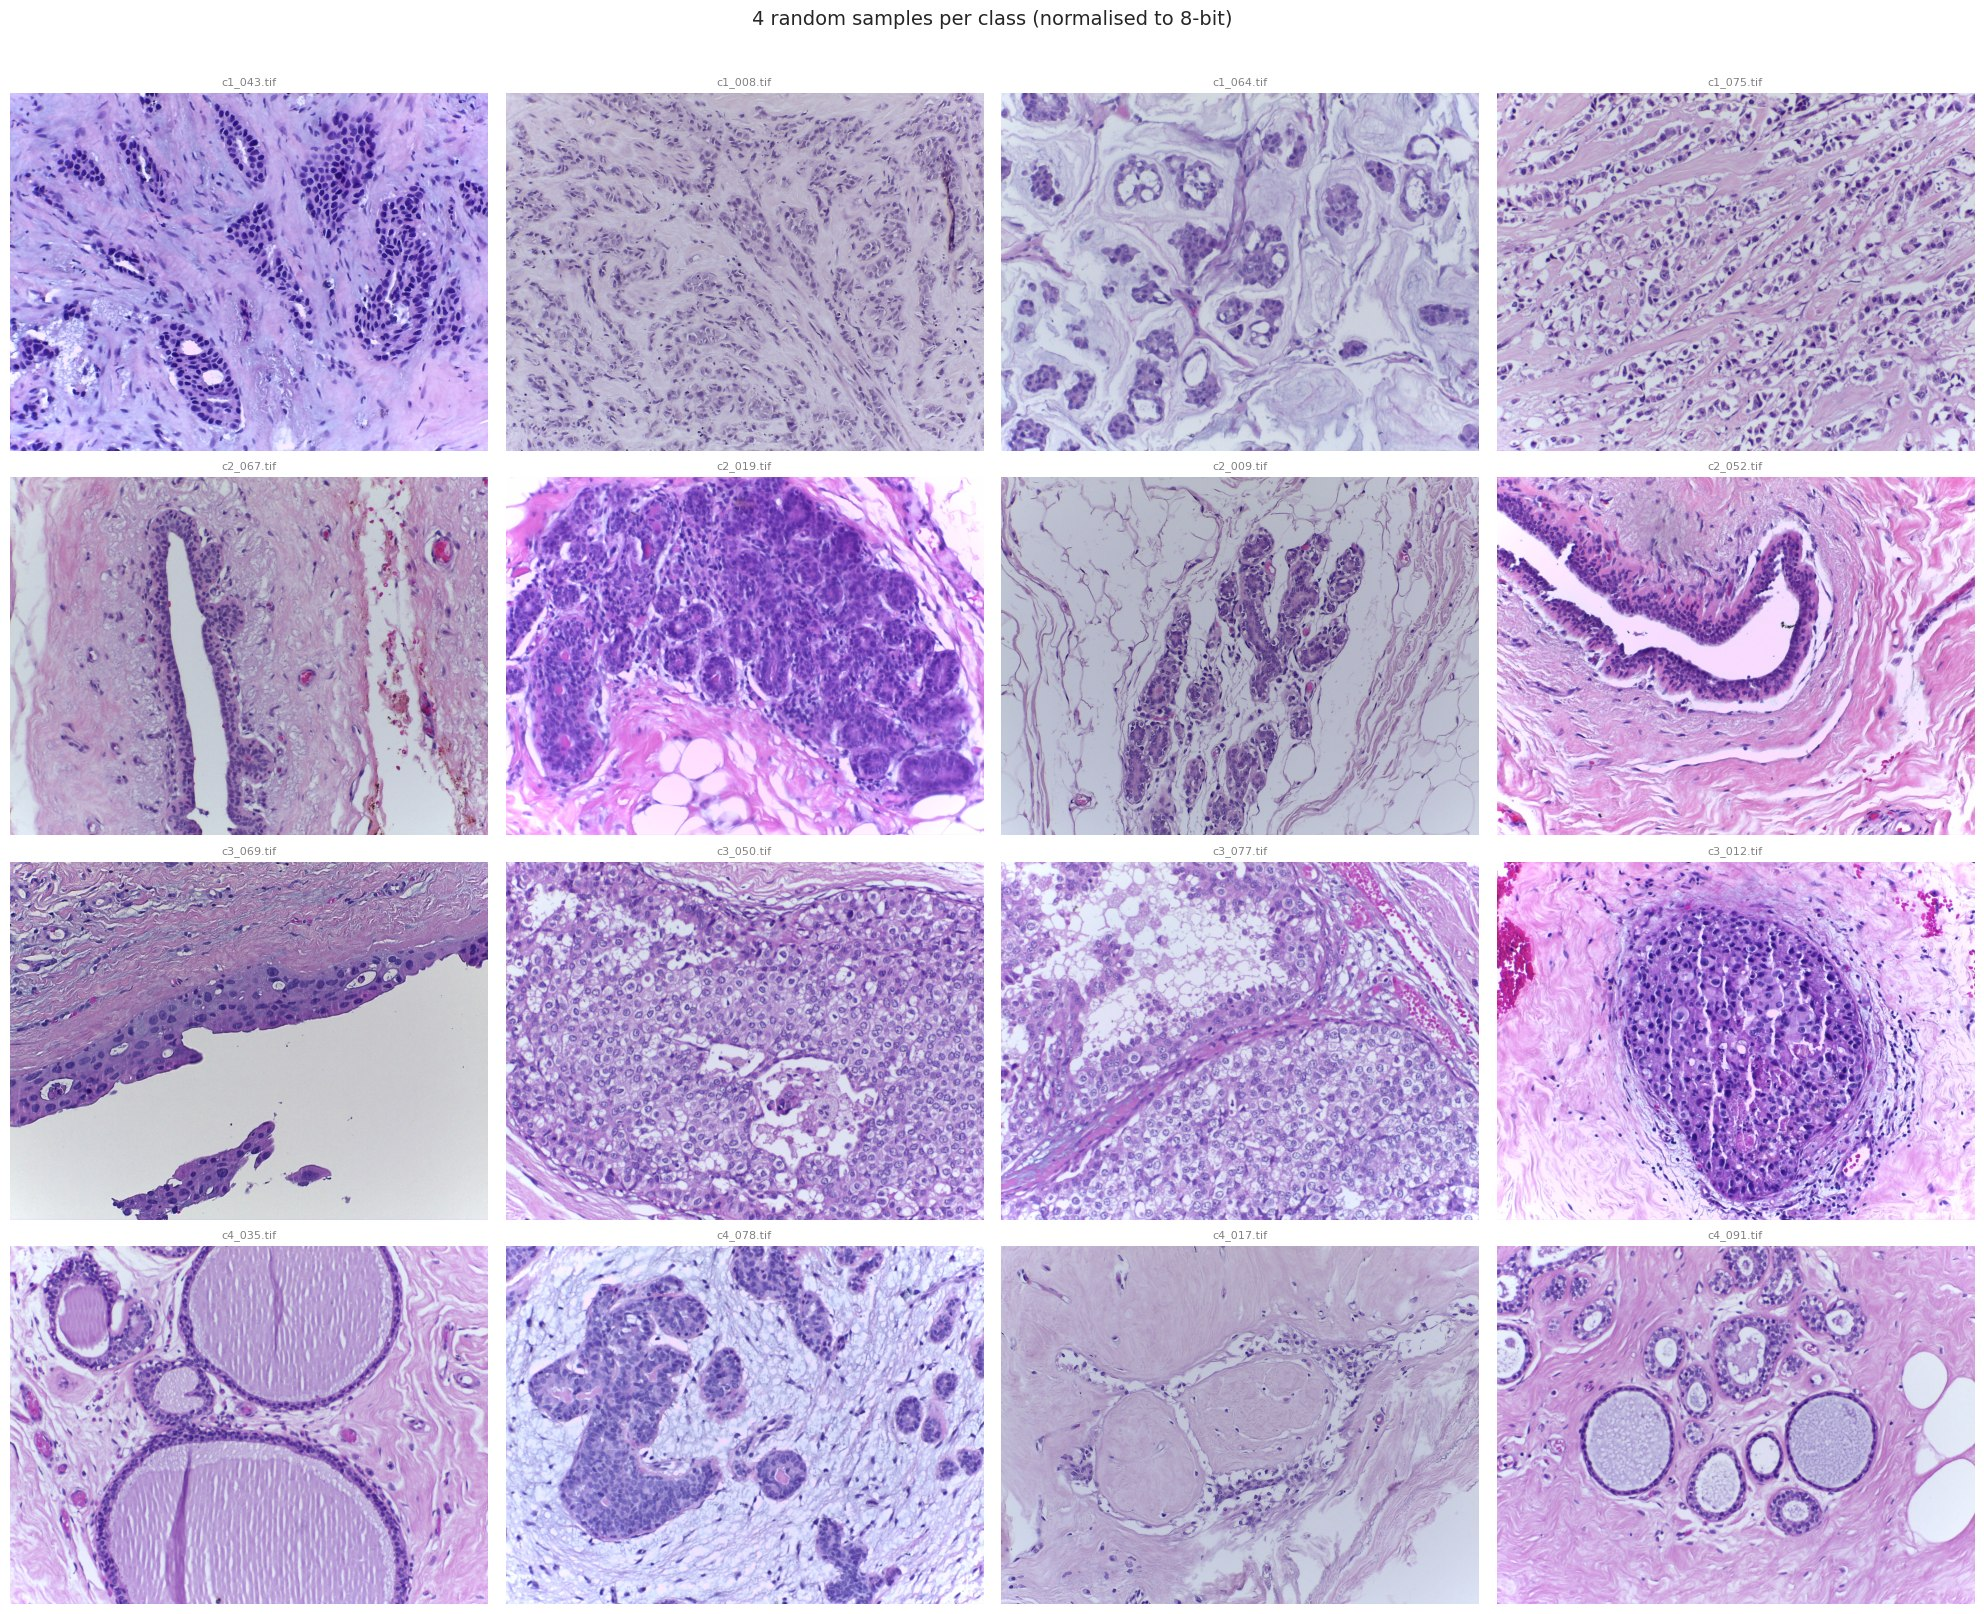

In [11]:
N = 4  # samples per class
rng = np.random.default_rng(42)

fig, axes = plt.subplots(len(classes), N, figsize=(N * 5, len(classes) * 4))

for row_idx, cls in enumerate(classes):
    cls_paths = df[df["class"] == cls]["path"].values
    chosen = rng.choice(cls_paths, size=N, replace=False)

    for col_idx, path in enumerate(chosen):
        img = load_image(path)
        ax = axes[row_idx, col_idx]
        ax.imshow(img)
        ax.axis("off")
        if col_idx == 0:
            ax.set_ylabel(cls, fontsize=14, fontweight="bold", labelpad=8)
        ax.set_title(os.path.basename(path), fontsize=8, color="gray")

plt.suptitle("4 random samples per class (normalised to 8-bit)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## Step 8 – Lets do a quick leakage check

100 images per class at 2048×1536 is the shape of images *tiled out of larger whole-slide scans*.

If the dataset was built by cutting a handful of WSIs into tiles and then assigning class labels,
adjacent files may come from the **same physical slide**. 

If we do a random train/test split on that and the same tissue ends up on both sides, the model memorises slides, not tissue types, and the
validation score will not be true.

Two quick checks:

1. **Visually** — adjacent-index images within a class (`*_00.tif` vs `*_01.tif`) should look like
   different samples, not neighbouring crops of the same slide.
2. **Via TIFF metadata** — dump the tags and look for shared scanner / acquisition identifiers that
   would tie images together.


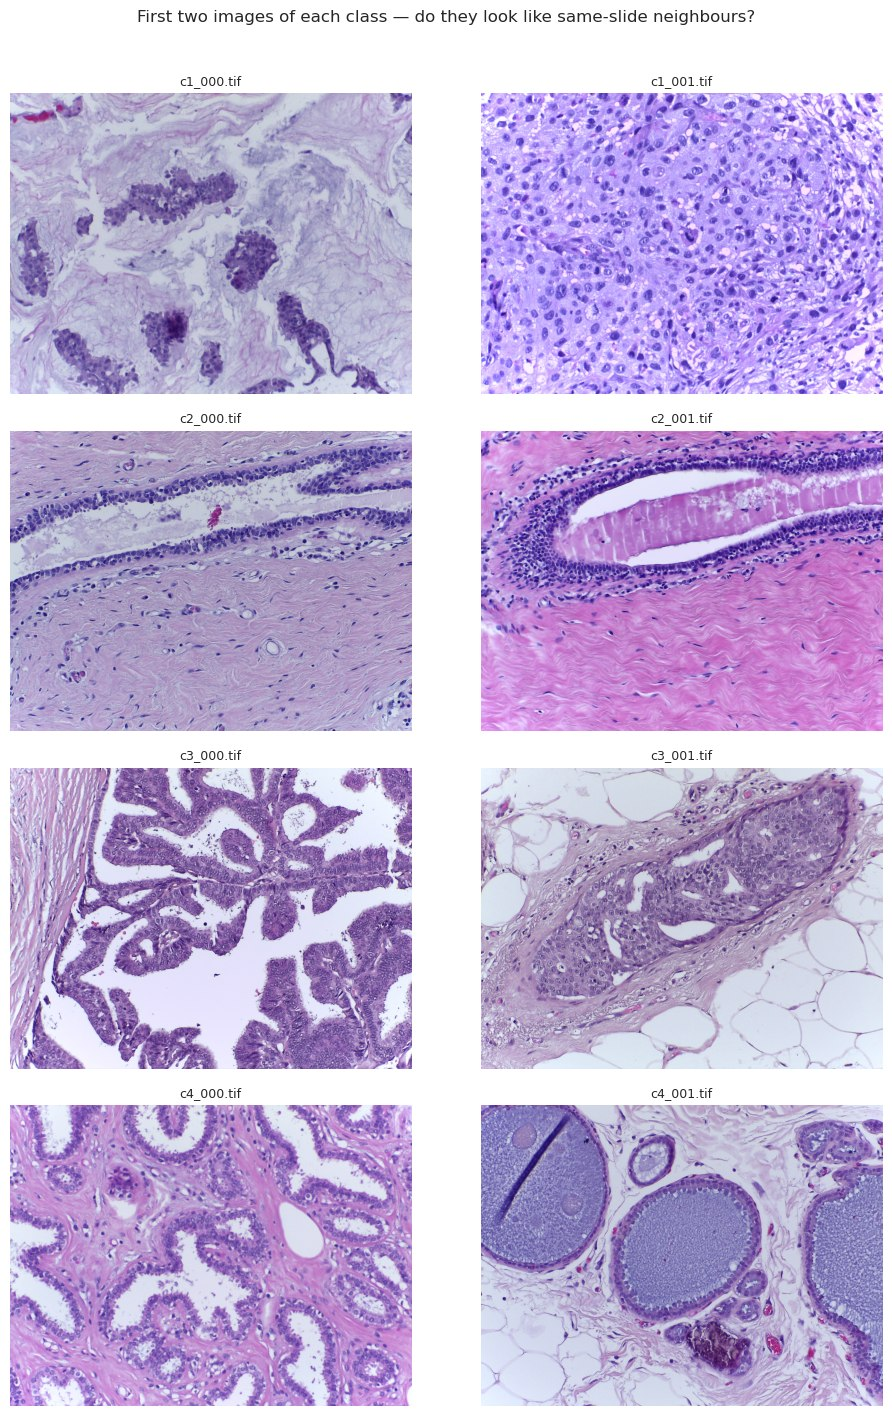

In [12]:
fig, axes = plt.subplots(len(classes), 2, figsize=(10, len(classes) * 3.5))

for row_idx, cls in enumerate(classes):
    cls_paths = sorted(df[df["class"] == cls]["path"].tolist())
    for col_idx in range(2):
        img = load_image(cls_paths[col_idx])
        ax = axes[row_idx, col_idx]
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(os.path.basename(cls_paths[col_idx]), fontsize=9)
    axes[row_idx, 0].set_ylabel(cls, fontsize=12, fontweight="bold", labelpad=8)

plt.suptitle("First two images of each class — do they look like same-slide neighbours?",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


If these pairs look like **distinct tissue samples** (different architecture, different stain
intensity, unrelated slide backgrounds), we're likely safe assuming one-slide-per-image and a
stratified split is appropriate.

If instead they look like **neighbouring tiles of the same piece
of tissue** / continuous structures crossing from one image to the next, near-identical stain, 
we'd need to group by slide ID and use `StratifiedGroupKFold` so tiles from the same slide never
straddle a fold boundary.


Ok, Now let's check a small set of descriptive TIFF tags. 

Any shared scanner/software/date string across images would suggest they came from the same acquisition run (another leakage signal).


In [13]:

INTERESTING_TAGS = {
    270: "ImageDescription",
    271: "Make",
    272: "Model",
    305: "Software",
    306: "DateTime",
    33432: "Copyright",
}

for cls in classes:
    path = df[df["class"] == cls]["path"].iloc[0]
    with tifffile.TiffFile(path) as tif:
        page = tif.pages[0]
        print(f"\n{os.path.basename(path)}  ({cls})")
        printed_any = False
        for tag_id, tag_name in INTERESTING_TAGS.items():
            if tag_id in page.tags:
                val = str(page.tags[tag_id].value)
                if len(val) > 120:
                    val = val[:117] + "..."
                print(f"  {tag_name:16s}: {val}")
                printed_any = True
        if not printed_any:
            print("  (no descriptive metadata tags present)")



c1_000.tif  (class1)
  (no descriptive metadata tags present)

c2_000.tif  (class2)
  (no descriptive metadata tags present)

c3_000.tif  (class3)
  (no descriptive metadata tags present)

c4_000.tif  (class4)
  (no descriptive metadata tags present)


### What we'll do about splits

**Check data leakage (Step 8).** Adjacent-index images within each class show **distinct tissue
architectures**, different glandular patterns, different stain intensities, no continuous
structures crossing from `*_000` to `*_001`. They don't look like neighbouring crops of the same
whole-slide image. But this is just an assumption.

**Metadata check.** The TIFF tag dump above returned **no descriptive metadata** (`Make`, `Model`,
`Software`, `DateTime`, `ImageDescription`) for any of the sampled files. There's no scanner or
acquisition identifier to group on even if we wanted to.

**Patient-level leakage is not detectable here.** What we've ruled out is *slide-level*
leakage (the same slide appearing on both sides of a split). We **cannot** rule out *patient-level*
leakage: two independent slides from the same patient landing in different folds would still be a
form of data leakage, since patients vary systematically in staining, tissue architecture, and
preparation artefacts. With no patient IDs, dates, or scanner strings in the data, we have no way
to check. 

At *n* = 400 this is an limitation of the dataset, not a choice we can
engineer around and put "patient-aware splits when IDs are available" in Future Work.

**Decision: `StratifiedKFold` (k = 5, fixed seed).** We have no evidence of WSI-tiling leakage and
no shared metadata to group by, so a standard stratified split is a good choice. We fix the
seed and save the fold indices alongside the final checkpoint for reproducibility.


## Summary of findings

| Property | Value |
|---|---|
| Classes | 4 (class1 – class4) |
| Images per class | 100 (perfectly balanced) |
| Image resolution | 1536 × 2048 px, 3-channel RGB |
| Bit-depth mix | 381 / 400 images are 16-bit (`uint16`); 19 are 8-bit (`uint8`) |
| Bit-depth fix | Rescale 16-bit → 8-bit at load (`>> 8`) → consistent `uint8` in `[0, 255]` |
| Leakage check | No WSI-tiling signature in adjacent-index images; no descriptive TIFF metadata → **`StratifiedKFold` (k = 5)** |
| Patient-level leakage | Not detectable (no patient IDs / acquisition metadata). Noted as a limitation |

